## Exercise 2 – Lactic Acid Inhibition of *Streptococcus cremoris*

Bibal et al. (1988, 1989) studied the inhibitory effect of lactic acid on the growth of 
*Streptococcus cremoris*. In this exercise, we analyse their data by fitting inhibition 
models and studying the effect of pH on growth.

---

### Part a – Relative Growth Rate vs Undissociated Acid Concentration

#### Assumptions
- The experiment is conducted under substrate saturation, so substrate limitation can be 
neglected.
- Only the **undissociated form** of lactic acid (HA) can cross the cell membrane and 
exert a toxic effect on growth. The dissociated lactate anion (A⁻) is assumed to have 
no inhibitory effect.
- The volume is constant, so concentrations are directly comparable.
- The system is at chemical equilibrium with respect to acid dissociation at the given pH.

#### Methodology

The total lactic acid concentration is given in g/L and must first be converted to molar 
units (mM):

$$P_{total} \, [\text{mM}] = \frac{p \, [\text{g/L}]}{M \, [\text{g/mol}]} \times 1000$$

where $M = 90.08$ g/mol is the molar mass of lactic acid.

The fraction of lactic acid that remains undissociated at a given pH is derived from the 
Henderson–Hasselbalch equation:

$$\text{fraction} = \frac{1}{1 + 10^{\text{pH} - \text{pK}_a}}$$

with $\text{pK}_a = 3.88$ and $\text{pH} = 6.3$. The undissociated acid concentration is 
then:

$$P = P_{total} \times \text{fraction}$$

The relative specific growth rate is defined as:

$$\frac{\mu(P)}{\mu(P=0)}$$

which is normalised to 1 at zero inhibitor concentration, making it independent of 
$\mu_{max}$ and allowing direct comparison across conditions.

#### Results and Interpretation

The plot shows that the relative growth rate decreases monotonically as the undissociated 
acid concentration increases. Even at low concentrations of undissociated acid (below 
1 mM), the growth rate is already significantly reduced. This confirms that the 
undissociated form of lactic acid is a potent inhibitor of growth in *S. cremoris*. 

Note that at pH = 6.3, which is well above the pKa of 3.88, only a very small fraction 
of the total lactic acid remains undissociated. Despite this, even these small 
concentrations are sufficient to cause strong inhibition, highlighting the high toxicity 
of the undissociated acid form at the intracellular level.

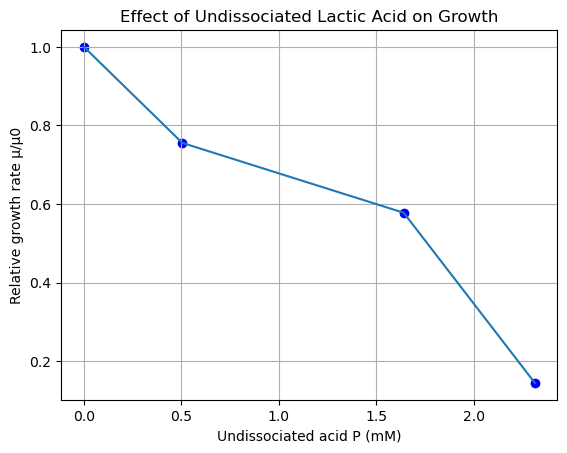

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0, 12, 39, 55])   # total lactic acid (g/L)
mu = np.array([0.9, 0.68, 0.52, 0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08   # g/mol

# Convert total acid to mol/L
p_molL = p_gL / M

# Convert to mM
p_mM = p_molL * 1000

# Fraction of undissociated acid
fraction = 1 / (1 + 10**(pH - pKa))

# Undissociated acid concentration
P = p_mM * fraction

# Relative growth rate
mu_rel = mu / mu[0]

# Plot
plt.figure()
plt.scatter(P, mu_rel, color='blue')
plt.plot(P, mu_rel)

plt.xlabel("Undissociated acid P (mM)")
plt.ylabel("Relative growth rate μ/μ0")
plt.title("Effect of Undissociated Lactic Acid on Growth")
plt.grid()

plt.show()

### Part b – Fitting the Haldane-type Inhibition Model (Model 1)

#### Model

The kinetics are assumed to follow:

$$\mu = \mu_{max} \frac{S}{K_s + S} \cdot \frac{1}{1 + \frac{P}{K_i}}$$

Since the experiment is conducted under **substrate saturation** ($S \gg K_s$), the 
Monod term $\frac{S}{K_s + S} \approx 1$, and therefore:

$$\mu \approx \frac{\mu_{max}}{1 + \frac{P}{K_i}}$$

This means that at $P = 0$, $\mu = \mu_{max}$, which is consistent with the 
first data point where no inhibitor is present and $\mu(P=0) = 0.9 \, \text{h}^{-1}$.

#### Methodology

To estimate the inhibition constant $K_i$, the model is linearised. Rearranging:

$$\frac{\mu_{max}}{\mu} - 1 = \frac{1}{K_i} \cdot P$$

This is linear in $P$ with slope $\frac{1}{K_i}$. A linear regression using 
`numpy.polyfit` is applied to extract the slope, from which:

$$K_i = \frac{1}{\text{slope}}$$

The first data point ($P = 0$) is excluded from the regression since it causes a 
division by zero in the linearised form.

#### Results and Interpretation

The inhibition constant obtained is:

$$K_i = 0.3559 \, \text{mM}$$

This is a very small value, indicating that even low concentrations of undissociated 
lactic acid are sufficient to halve the growth rate (since $K_i$ is the concentration 
at which $\mu = \mu_{max}/2$). This reflects the high sensitivity of *S. cremoris* to 
lactic acid inhibition, which is consistent with the fact that lactic acid is its own 
metabolic end product and accumulates during fermentation.

The model curve shows a hyperbolic decay in growth rate with increasing P. While the 
trend is captured qualitatively, the fit is not perfect — particularly at intermediate 
concentrations — suggesting that a different model form may describe the data better, 
which is explored in part c.

Ki = 0.35585194156583455 mM


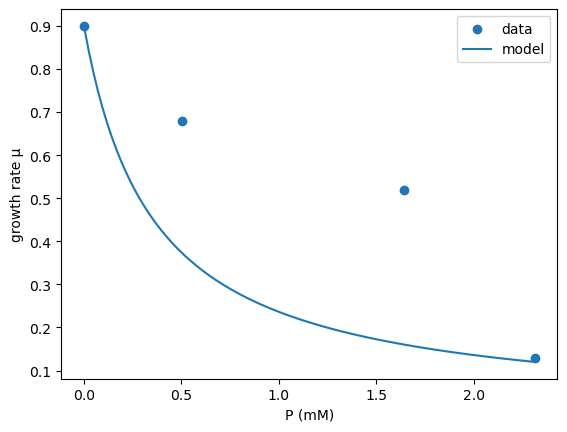

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0,12,39,55])
mu = np.array([0.9,0.68,0.52,0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08

# Convert g/L → mol/L
p_mol = p_gL / M

# Convert mol/L → mM
p_mM = p_mol * 1000

# fraction undissociated
fraction = 1/(1+10**(pH-pKa))

# undissociated acid
P = p_mM * fraction

# μmax
mu_max = mu[0]

# Linearization
Y = mu_max/mu - 1

# remove first point (division by zero issue)
P_fit = P[1:]
Y_fit = Y[1:]

# polyfit
a, b = np.polyfit(P_fit, Y_fit,1)

# inhibition constant
Ki = 1/a

print("Ki =",Ki,"mM")

# model curve
P_model = np.linspace(0,max(P),100)

mu_model = mu_max/(1 + P_model/Ki)

# plot
plt.scatter(P,mu,label="data")
plt.plot(P_model,mu_model,label="model")

plt.xlabel("P (mM)")
plt.ylabel("growth rate μ")
plt.legend()
plt.show()

### Part c – Comparing Model 1 and Model 2

#### Models

Two inhibition models are compared:

**Model 1** (from part b) — hyperbolic inhibition:

$$\mu = \frac{\mu_{max}}{1 + \frac{P}{K_i}}$$

This model predicts that growth asymptotically approaches zero but never fully stops, 
regardless of inhibitor concentration.

**Model 2** — linear inhibition:

$$\mu = \mu_{max} \left(1 - \frac{P}{P_{max}}\right)$$

Here $P_{max}$ is the undissociated acid concentration at which growth completely ceases. 
This model predicts a finite inhibitor concentration beyond which growth is zero.

#### Methodology

For Model 2, the equation is linearised by rearranging:

$$1 - \frac{\mu}{\mu_{max}} = \frac{1}{P_{max}} \cdot P$$

This is linear in $P$ with slope $\frac{1}{P_{max}}$, so:

$$P_{max} = \frac{1}{\text{slope}}$$

Again, `numpy.polyfit` is used for linear regression, excluding the first point ($P=0$) 
to avoid a trivial zero.

To decide which model better describes the data, both are plotted against the 
experimental points and compared visually. The R² coefficient is used as a quantitative 
measure of goodness of fit:

$$R^2 = 1 - \frac{\sum_i (\mu_i - \hat{\mu}_i)^2}{\sum_i (\mu_i - \bar{\mu})^2}$$

#### Results and Interpretation

The fitted parameter for Model 2 is:

$$P_{max} = 3.13 \, \text{mM}$$

From the plot, **Model 2 (linear)** provides a visibly better fit to the experimental 
data across all measured concentrations. Model 1 decays too rapidly at low P and 
underestimates growth at intermediate concentrations, because the hyperbolic form gives 
disproportionate weight to the lowest concentration point. Model 2 captures the 
approximately linear decline in growth rate with increasing undissociated acid 
concentration more accurately.

This is confirmed quantitatively by the R² values: Model 1 achieves R² = 0.2920, 
while Model 2 achieves R² = 0.9206, indicating a substantially better fit to the 
experimental data.

Biologically, Model 2 is also more intuitive: it predicts a finite lethal concentration 
$P_{max}$, beyond which growth stops entirely. This is consistent with experimental 
observations that lactic acid bacteria have a maximum tolerable acid concentration. 
Model 2 is therefore selected as the preferred inhibition model for the subsequent 
analysis in part d.

Ki = 0.35585194156583455
Pmax = 3.1348220500148956
R² Model 1 (Ki): 0.2920
R² Model 2 (Pmax): 0.9206


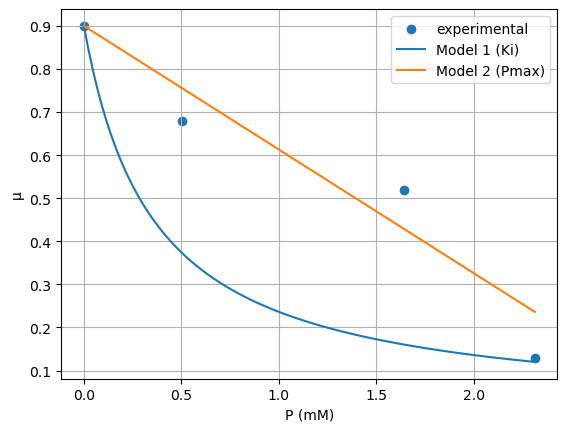

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Data
p_gL = np.array([0,12,39,55])
mu = np.array([0.9,0.68,0.52,0.13])

# Constants
pH = 6.3
pKa = 3.88
M = 90.08

# Convert total acid to mM
p_mM = (p_gL/M)*1000

# Undissociated fraction
fraction = 1/(1+10**(pH-pKa))

P = p_mM * fraction

# μmax
mu_max = mu[0]

#################################
# Model 1 (from part b)
#################################

Y1 = mu_max/mu - 1

P_fit = P[1:]
Y1_fit = Y1[1:]

a1,b1 = np.polyfit(P_fit,Y1_fit,1)

Ki = 1/a1

#################################
# Model 2 (this question)
#################################

Y2 = 1 - mu/mu_max

P_fit = P[1:]
Y2_fit = Y2[1:]

a2,b2 = np.polyfit(P_fit,Y2_fit,1)

Pmax = 1/a2

print("Ki =",Ki)
print("Pmax =",Pmax)

#################################
# Create curves
#################################

P_model = np.linspace(0,max(P),100)

# Model 1
mu_model1 = mu_max/(1+P_model/Ki)

# Model 2
mu_model2 = mu_max*(1-P_model/Pmax)

#################################
# R² for both models to quantitatively justify model selection
#################################

ss_tot = np.sum((mu - np.mean(mu))**2)
R2_1 = 1 - np.sum((mu - mu_max/(1+P/Ki))**2) / ss_tot
R2_2 = 1 - np.sum((mu - mu_max*(1-P/Pmax))**2) / ss_tot
print(f"R² Model 1 (Ki): {R2_1:.4f}")
print(f"R² Model 2 (Pmax): {R2_2:.4f}")

#################################
# Plot
#################################

plt.scatter(P,mu,label="experimental")

plt.plot(P_model,mu_model1,label="Model 1 (Ki)")
plt.plot(P_model,mu_model2,label="Model 2 (Pmax)")

plt.xlabel("P (mM)")
plt.ylabel("μ")
plt.legend()
plt.grid()

plt.show()

### Part d – Effect of pH on Relative Growth Rate

#### Methodology

Using Model 2 selected in part c:

$$\frac{\mu}{\mu_{max}} = 1 - \frac{P}{P_{max}}$$

where $P$ is the undissociated acid concentration (mM). At a fixed total lactic acid 
concentration $c$ (mM), $P$ depends on pH via the Henderson–Hasselbalch equation:

$$P(\text{pH}) = \frac{c}{1 + 10^{\text{pH} - \text{pK}_a}}$$

Substituting into Model 2:

$$\frac{\mu}{\mu_{max}} = 1 - \frac{c}{P_{max}\left(1 + 10^{\text{pH} - \text{pK}_a}\right)}$$

Growth stops when $\mu/\mu_{max} = 0$, i.e. when $P = P_{max}$. Solving for pH:

$$\frac{c}{1 + 10^{\text{pH}_{stop} - \text{pK}_a}} = P_{max}$$

$$\text{pH}_{stop} = \text{pK}_a + \log_{10}\left(\frac{c}{P_{max}} - 1\right)$$

The relative growth rate is computed over a pH range of 2.5 to 7.0 for two total lactic 
acid concentrations: 1 g/L and 10 g/L. Negative values are clipped to zero since growth 
cannot be negative.

#### Results and Interpretation

| Total lactic acid | pH at which growth stops |
|---|---|
| 1 g/L | 4.29 |
| 10 g/L | 5.42 |

The plot shows that at low pH, the undissociated acid fraction is high, resulting in 
strong inhibition and zero growth. As pH increases, more of the acid dissociates into 
the non-toxic lactate form, so the inhibitory concentration P decreases and growth 
resumes.

For the higher concentration (10 g/L), growth is suppressed up to a significantly higher 
pH (5.42 vs 4.29), because more total acid is present and a larger fraction must 
dissociate before P falls below $P_{max}$. This has important practical implications for 
fermentation: at higher lactic acid titres, the culture medium must be maintained at a 
higher pH to sustain growth. This is commonly achieved by pH control via base addition 
in industrial fermenters. Without pH control, lactic acid accumulation during 
fermentation will progressively lower the pH, increasing the undissociated fraction and 
eventually causing complete growth inhibition — a classic example of **product 
inhibition** in fermentation systems.

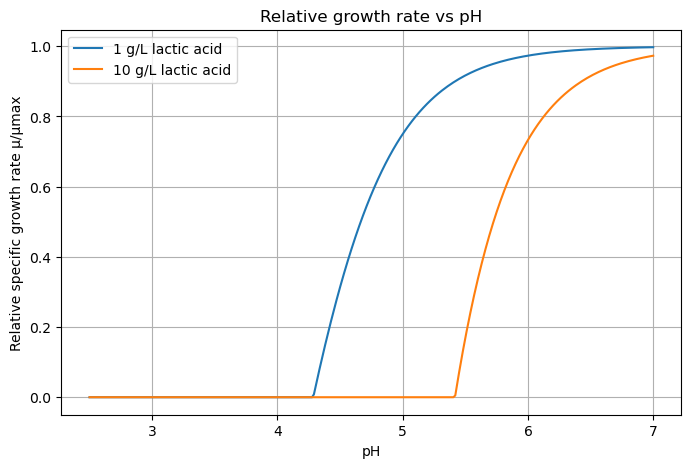

For 1 g/L, growth stops at pH = 4.285981729553904
For 10 g/L, growth stops at pH = 5.417406396276615


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# constants
pKa = 3.88
M = 90.08   # g/mol

# from part (c), use your fitted value
Pmax = 3.13   # mM   <-- replace by your exact computed value if needed

# total lactic acid concentrations (g/L)
c1_gL = 1
c2_gL = 10

# convert to mM
c1_mM = c1_gL / M * 1000
c2_mM = c2_gL / M * 1000

# pH range
pH = np.linspace(2.5, 7.0, 300)

# undissociated acid concentration as a function of pH
P1 = c1_mM / (1 + 10**(pH - pKa))
P2 = c2_mM / (1 + 10**(pH - pKa))

# relative growth rate using model from (c)
mu_rel_1 = 1 - P1 / Pmax
mu_rel_2 = 1 - P2 / Pmax

# optional: clip negative values to zero
mu_rel_1 = np.maximum(mu_rel_1, 0)
mu_rel_2 = np.maximum(mu_rel_2, 0)

# plot
plt.figure(figsize=(8,5))
plt.plot(pH, mu_rel_1, label='1 g/L lactic acid')
plt.plot(pH, mu_rel_2, label='10 g/L lactic acid')

plt.xlabel('pH')
plt.ylabel('Relative specific growth rate μ/μmax')
plt.title('Relative growth rate vs pH')
plt.grid(True)
plt.legend()
plt.show()

# pH at which growth stops
pH_stop_1 = pKa + np.log10(c1_mM / Pmax - 1)
pH_stop_2 = pKa + np.log10(c2_mM / Pmax - 1)

print("For 1 g/L, growth stops at pH =", pH_stop_1)
print("For 10 g/L, growth stops at pH =", pH_stop_2)